```28/07/2025 - Gabriel A. Amici```

# Implementando classes para a biblioteca ```emerald```

### Objetivos:
- Compactar código
- Reutilizar rotinas similares
- Facilitar uso da biblioteca

### Classes base:
- ```Potential```
- ```Field```
- ```Particle```
- ```System```

In [3]:
import numpy as np

In [45]:


class Potential:
	"""
	Base class for 1D potentials, responsible for calculating the potential 
	and its derivatives, as well as the classical return points.
	"""

	def __init__(self, *args, **kwargs):
		self.name    = None
		self.acronym = None
		pass
	
	def value(self, position_array):
		"""
		Potential evaluated at a range of positions

		Parameters
		----------
		position_array : array-like
			Array of positions at which to evaluate the potential

		Returns
		-------
		potential_values : array-like
			Array of potential values corresponding to the input positions
		"""
		r = np.asarray(position_array)
		pass
	
	def first_derivative(self, position_array):
		"""
		1st derivative of the potential evaluated for a range of positions

		Parameters
		----------
		position_array : array-like
			Array of positions at which to evaluate the derivative

		Returns
		-------
		first_derivative_values : array-like
			Array of first derivative values corresponding to the input positions
		"""
		r = np.asarray(position_array)
		pass
	
	def second_derivative(self, position_array):
		"""
		2nd derivative of the potential evaluated for a range of positions

		Parameters
		----------
		position_array : array-like
			Array of positions at which to evaluate the second derivative

		Returns
		-------
		second_derivative_values : array-like
			Array of second derivative values corresponding to the input positions
		"""
		r = np.asarray(position_array)
		pass
	
	def return_points(self):
		"""Classical return points of the potential"""
		pass

A partir da classe base é possível implementar potenciais como classes herdadas:

In [ ]:
class MorseSoftCoulomb(Potential):
    """
    Morse-soft-Coulomb potential (MsC) is a 1D soft potential with a Morse 
    barrier at the origin. The parameter 'alpha' controls the well depth and
    barrier hardness.
    """
    
    def __init__(self, alpha):
        super().__init__()
        self.name       = "Morse-soft-Coulomb"
        self.acronym    = "MsC"
        self.alpha      = alpha
        self.well_depth = 1 / alpha
        self.beta       = 1 / (alpha * np.sqrt(2))
    
    def value(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = -1 / np.sqrt(r**2 + self.alpha**2)
        morse = self.well_depth * (np.exp(-2 * self.beta * r) - 2 * np.exp(-self.beta * r))
        
        return np.where(r > 0, coulomb, morse)
    
    def first_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = r*(r**2 + self.alpha**2)**(-3/2)
        morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
        
        return np.where(r > 0, coulomb, morse)
    
    def second_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = (r**2 + self.alpha**2)**(-3/2) - 3*r**2*(r**2 + self.alpha**2)**(-5/2)
        morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
        
        return np.where(r > 0, coulomb, morse)
    
    def return_points(self, energy: float = 0.):
        
        if energy < -self.well_depth:
            Warning(f"Energy must be greater than the well depth ({-self.well_depth})")
            return (None, None) 

        rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
        rM = np.sqrt( 1/(energy**2) - self.alpha**2 )
        
        if energy >= 0:
            return (rm, None)
        else:
            return (rm, rM)
        
        

    
    

In [57]:
msc = MorseSoftCoulomb(alpha=0.5)

In [58]:
msc.name

'Morse-soft-Coulomb'

In [52]:
import matplotlib.pyplot as plt

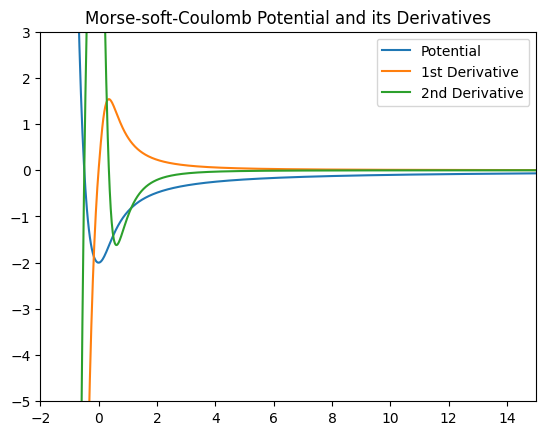

In [59]:
r = np.linspace(-2, 15, 1000)

plt.title(f"{msc.name} Potential and its Derivatives")
plt.plot(r, msc.value(r), label='Potential')
plt.plot(r, msc.first_derivative(r), label='1st Derivative')
plt.plot(r, msc.second_derivative(r), label='2nd Derivative')
plt.xlim(-2, 15)
plt.ylim(-5, 3)
plt.legend()
plt.show()